In [12]:
import mrcfile
import mdocfile
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
import mdocfile
import pandas as pd

In [3]:
with mrcfile.open("/data/elferich/CryoTEM/Johannes_20210803/ERHoxB8undiff2/record_lamella22.mrc") as mrc:
    records = mrc.data.copy()

In [4]:
records.shape

(458, 2046, 2880)

In [10]:
o = []
for r in records:
    i = np.fft.fft2(r)
    res = ndimage.fourier_gaussian(i,sigma=50)
    res = np.fft.ifft2(res).real
    res = res > 0.5 * np.max(res)
    o.append(res)
masks = np.array(o)

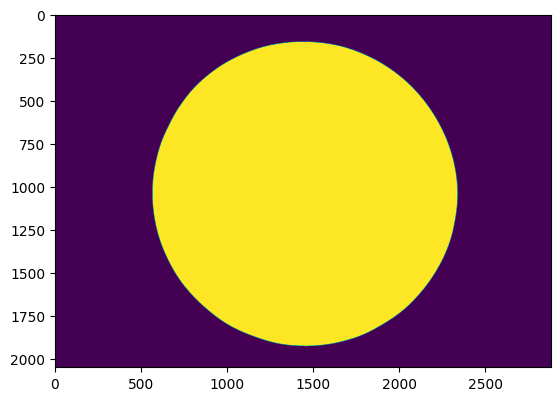

In [7]:
result = np.fft.ifft2(result)

In [ ]:
plt.imshow(result[0])

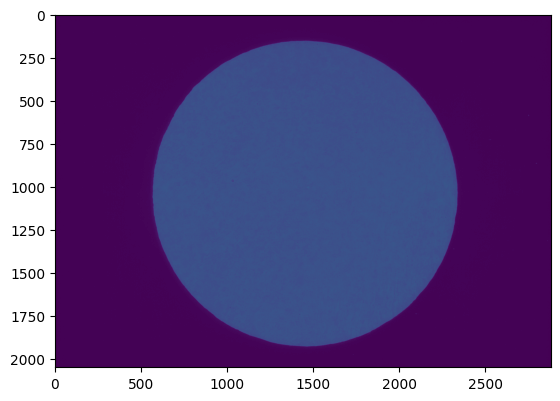

In [ ]:
plt.imshow(records[0])

In [15]:
mdoc_data = mdocfile.read("/data/elferich/CryoTEM/Johannes_20210803/ERHoxB8undiff2/record_lamella22.mrc.mdoc")
IS_to_camera = np.array([13374,6053.4,6394.1,-13172]).reshape(2,2)


result_tiles = pd.DataFrame(
    {
        "tile_filename": pd.Series(dtype="object"),
        "tile_movie_filename": pd.Series(dtype="object"),
        "tile_pixel_size": pd.Series(dtype="float"),
        "tile_x_size": pd.Series(dtype="int"),
        "tile_y_size": pd.Series(dtype="int"),
        "tile_orig_x_size": pd.Series(dtype="int"),
        "tile_orig_y_size": pd.Series(dtype="int"),
        "tile_x_crop_center": pd.Series(dtype="int"),
        "tile_y_crop_center": pd.Series(dtype="int"),
        "tile_mask_filename": pd.Series(dtype="object"),
        "tile_plotted_result_filename": pd.Series(dtype="object"),
        "tile_image_shift_x": pd.Series(dtype="float"),
        "tile_image_shift_y": pd.Series(dtype="float"),
        "tile_image_shift_pixel_x": pd.Series(dtype="int"),
        "tile_image_shift_pixel_y": pd.Series(dtype="int"),
        "tile_microscope_focus": pd.Series(dtype="float"),
        "tile_defocus": pd.Series(dtype="float"),
        "tile_acquisition_time": pd.Series(dtype="int"),
    }
)


In [21]:

for i, item in mdoc_data.iterrows():

    # Initially convert image shift to unbinned pixels
    image_shift = np.array(item["ImageShift"])
    shift_in_camera_pixels = np.dot(IS_to_camera, image_shift)
    shift_in_image_pixel = shift_in_camera_pixels / 2
    crop_x = 0
    crop_y = 0
    crop_center_x = 0
    crop_center_y = 0
    mdoc_data.loc[i, "tile_image_shift_pixel_x"] = (
        shift_in_image_pixel[0] + crop_x + crop_center_x
    )
    mdoc_data.loc[i, "tile_image_shift_pixel_y"] = (
        -shift_in_image_pixel[1] + crop_y + crop_center_y
    )
mdoc_data["tile_pixel_size"] = mdoc_data["PixelSpacing"]



In [40]:
from decolace.processing.decolace_processing import find_tile_pairs

tp = find_tile_pairs(mdoc_data,9000)

In [27]:
import multiprocessing
from functools import partial
from rich.progress import track
from scipy.ndimage import binary_erosion, mean
def determine_shift_by_cc2(
    im1,
    im2,
    im1_mask,
    im2_mask,
    erode_mask: float = 0,
    filter_cutoff_frequency_ratio: float = 0.02,
    filter_order=4.0,
    mask_size_cutoff: int = 100,
    overlap_ratio: float = 0.1,
    debug: bool = False,
    debug_object = {}
):
    

    
    if erode_mask > 0:
        reference_mask = reference_mask > 0.5
        moving_mask = moving_mask > 0.5
        reference_mask = binary_erosion(im1_mask, iterations=erode_mask)
        moving_mask = binary_erosion(im2_mask, iterations=erode_mask)

    # Transform mask2
    diff = (
        int(im2["tile_image_shift_pixel_x"] - im1["tile_image_shift_pixel_x"]),
        int(im2["tile_image_shift_pixel_y"] - im1["tile_image_shift_pixel_y"]),
    ) 
    tform = transform.SimilarityTransform(translation=(diff[0], diff[1])).inverse
    moving_mask = transform.warp(moving_mask, tform, output_shape=reference_mask.shape)
    mask = np.minimum(reference_mask, moving_mask) > 0.9
    if np.sum(mask) < mask_size_cutoff:
        return None
    # Get bounding box of the mask
    bbox = np.array([np.min(np.nonzero(mask)[0]), np.max(np.nonzero(mask)[0]), np.min(np.nonzero(mask)[1]), np.max(np.nonzero(mask)[1])])
    # Calculate bounding box for moving
    bbox_moving = np.array([bbox[0] - diff[1], bbox[1] - diff[1], bbox[2] - diff[0], bbox[3] - diff[0]]) 
    mask = mask[bbox[0]:bbox[1], bbox[2]:bbox[3]]
    

    with mrcfile.open(im1["tile_filename"]) as mrc:
        reference = np.copy(mrc.data[0])
        # Cut out the bounding box
        reference = reference[bbox[0]:bbox[1], bbox[2]:bbox[3]]
        reference = filters.butterworth(
            reference,
            cutoff_frequency_ratio=filter_cutoff_frequency_ratio,
            order=filter_order,
            high_pass=False,
        )
        if debug:
            debug_object["reference"] = reference.copy()
    with mrcfile.open(im2["tile_filename"]) as mrc:
        moving = np.copy(mrc.data[0])
        # Cut out the bounding box
        moving = moving[bbox_moving[0]:bbox_moving[1], bbox_moving[2]:bbox_moving[3]]
        moving = filters.butterworth(
            moving,
            cutoff_frequency_ratio=filter_cutoff_frequency_ratio,
            order=filter_order,
            high_pass=False,
        )
        if debug:
            debug_object["moving"] = moving.copy()
    
def calculate_shifts(row_pairs: list, num_proc: int = 1, erode_mask: int = 0, filter_cutoff_frequency_ratio: float = 0.02, filter_order: float = 4.0, mask_size_cutoff: int = 100, overlap_ratio: float = 0.1):
    pool = multiprocessing.Pool(processes=num_proc)

    # map the worker function to the input data using the pool
    results = pool.imap_unordered(
        partial(determine_shift_by_cc2, erode_mask=erode_mask, filter_cutoff_frequency_ratio=filter_cutoff_frequency_ratio, filter_order=filter_order,mask_size_cutoff=mask_size_cutoff, overlap_ratio=overlap_ratio), row_pairs
    )
    shifts = []
    # use the rich.progress module to track the progress of the results
    for result in track(
        results,
        total=len(row_pairs),
        description="Calculating shifts from pairwise cross-correlations",
    ):
        shifts.append(result)
        # process the result here

    shifts = pd.DataFrame([a for a in shifts if a is not None])
    return shifts

,ZValue,TiltAngle,StagePosition,StageZ,Magnification,MagIndex,Intensity,PixelSpacing,ExposureDose,DoseRate,...,Voltage,DataMode,ImageSize,ImageFile,titles,image_shift_pixel_x,image_shift_pixel_y,tile_image_shift_pixel_x,tile_image_shift_pixel_y,tile_pixel_size
0,0,0.005999,"(614.504, -416.103)",-16.4062,64000.0,29,0.111955,2.66662,0.0,10.98390,...,300.0,1,"(2880, 2046)",record_lamella22.mrc,[[T = SerialEM: UMass_Krios Camera -> 0:Ceta 1...,-3048.906807,-39942.397648,-3048.906807,-39942.397648,2.66662
1,1,0.005999,"(614.506, -416.103)",-16.4062,64000.0,29,0.111955,2.66662,0.0,11.04150,...,300.0,1,"(2880, 2046)",record_lamella22.mrc,[[T = SerialEM: UMass_Krios Camera -> 0:Ceta 1...,-240.544809,-38911.785370,-240.544809,-38911.785370,2.66662
2,2,0.005999,"(614.505, -416.103)",-16.4062,64000.0,29,0.111955,2.66662,0.0,11.11380,...,300.0,1,"(2880, 2046)",record_lamella22.mrc,[[T = SerialEM: UMass_Krios Camera -> 0:Ceta 1...,2567.786922,-37881.238952,2567.786922,-37881.238952,2.66662
3,3,0.005999,"(614.505, -416.104)",-16.4062,64000.0,29,0.111955,2.66662,0.0,11.06330,...,300.0,1,"(2880, 2046)",record_lamella22.mrc,[[T = SerialEM: UMass_Krios Camera -> 0:Ceta 1...,5376.118653,-36850.692535,5376.118653,-36850.692535,2.66662
4,4,0.005999,"(614.505, -416.103)",-16.4062,64000.0,29,0.111955,2.66662,0.0,11.16730,...,300.0,1,"(2880, 2046)",record_lamella22.mrc,[[T = SerialEM: UMass_Krios Camera -> 0:Ceta 1...,8184.450384,-35820.146118,8184.450384,-35820.146118,2.66662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
453,453,0.005999,"(614.481, -416.112)",-16.4062,64000.0,29,0.111955,2.66662,0.0,8.37630,...,300.0,1,"(2880, 2046)",record_lamella22.mrc,[[T = SerialEM: UMass_Krios Camera -> 0:Ceta 1...,-4522.788603,21185.519211,-4522.788603,21185.519211,2.66662
454,454,0.005999,"(614.484, -416.111)",-16.4062,64000.0,29,0.111955,2.66662,0.0,8.39670,...,300.0,1,"(2880, 2046)",record_lamella22.mrc,[[T = SerialEM: UMass_Krios Camera -> 0:Ceta 1...,-1714.456872,22216.065629,-1714.456872,22216.065629,2.66662
455,455,0.005999,"(614.482, -416.111)",-16.4062,64000.0,29,0.111955,2.66662,0.0,8.41972,...,300.0,1,"(2880, 2046)",record_lamella22.mrc,[[T = SerialEM: UMass_Krios Camera -> 0:Ceta 1...,1093.874859,23246.612046,1093.874859,23246.612046,2.66662
456,456,0.005999,"(614.482, -416.111)",-16.4062,64000.0,29,0.111955,2.66662,0.0,8.51189,...,300.0,1,"(2880, 2046)",record_lamella22.mrc,[[T = SerialEM: UMass_Krios Camera -> 0:Ceta 1...,3902.206590,24277.158463,3902.206590,24277.158463,2.66662
